In [8]:
from importlib import reload

import pandas as pd

import bsd

from bsd import data
from bsd import imports
from bsd import scenarios
from bsd import constants
from bsd import plot


load_daily_exports

In [2]:
exports_df = data.load_daily_exports(path=constants.DATA_PATH_EXPORTS, domestic_only=False)

exports_df.loc[::-1]

,date,GWh_d,month,year,is_winter
1556,2026-05-30 06:00:00,18.214985,5,2026,False
1555,2026-05-29 06:00:00,138.559228,5,2026,False
1554,2026-05-28 06:00:00,153.809663,5,2026,False
1553,2026-05-27 06:00:00,142.203934,5,2026,False
1552,2026-05-26 06:00:00,136.227114,5,2026,False
...,...,...,...,...,...
4,2022-03-05 06:00:00,1768.196521,3,2022,True
3,2022-03-04 06:00:00,1761.277985,3,2022,True
2,2022-03-03 06:00:00,1731.488972,3,2022,True
1,2022-03-02 06:00:00,1711.102401,3,2022,True


In [3]:
print(f"Min date: {exports_df.date.min()}"
      f"\nMax date: {exports_df.date.max()}")

Min date: 2022-03-01 06:00:00
Max date: 2026-05-30 06:00:00


load_demand_proxy

In [4]:
data.load_demand_proxy(data.DATA_PATH_IMPORTS, data.DATA_PATH_EXPORTS)

,date,demand_GWh_d,month,year,is_winter,imports_GWh_d
0,2025-01-01 06:00:00,336.704272,1,2025,True,322.171812
1,2025-01-02 06:00:00,378.584148,1,2025,True,330.216114
2,2025-01-03 06:00:00,354.143187,1,2025,True,372.323078
3,2025-01-04 06:00:00,344.856951,1,2025,True,366.650808
4,2025-01-05 06:00:00,361.563556,1,2025,True,351.646484
...,...,...,...,...,...,...
508,2026-05-24 06:00:00,93.294391,5,2026,False,272.313964
509,2026-05-25 06:00:00,107.926368,5,2026,False,277.097245
510,2026-05-26 06:00:00,111.173490,5,2026,False,251.942751
511,2026-05-27 06:00:00,116.614591,5,2026,False,265.441744


Imports

In [ ]:
imports_result = imports.compute_monthly_imports(scenarios.DEFAULT_SCENARIOS_DICT)

imports_result

{'S1': 10    183.295759
 11    147.839996
 12    137.115946
 1     112.982734
 2     120.173653
 3     153.870364
 dtype: float64,
 'S2': 10    212.502340
 11    159.832741
 12    141.577177
 1     134.953986
 2     148.888172
 3     195.835774
 dtype: float64,
 'S3': 10    237.007753
 11    230.551663
 12    150.043834
 1     164.164400
 2     185.359124
 3     215.450407
 dtype: float64,
 'S4': 10    299.191254
 11    284.433801
 12    259.711864
 1     213.760395
 2     215.020541
 3     253.569341
 dtype: float64,
 'S5': 10    356.896002
 11    341.951263
 12    340.882302
 1     272.035111
 2     243.888215
 3     350.435526
 dtype: float64}

In [ ]:
conditional_s, unconditional_s = imports.compute_import_benchmarks()


In [8]:
pd.concat([conditional_s, unconditional_s], axis=1).rename(
    columns={0: "conditional", 1: "unconditional"}
)


,conditional,unconditional
10,360.866592,589.587467
11,351.593908,635.066763
12,387.525312,390.767984
1,217.264251,365.551508
2,258.303863,313.542308
3,742.691219,820.221997


Analysis

In [9]:
from bsd import load_daily_imports

PEAK_DEMAND_GWH_D = 370.0


In [6]:
daily = load_daily_imports()

daily

,date,GWh_d,month,year,is_winter,levy_in_force
0,2022-03-01 06:00:00,701.857089,3,2022,True,False
1,2022-03-02 06:00:00,758.422918,3,2022,True,False
2,2022-03-03 06:00:00,696.757895,3,2022,True,False
3,2022-03-04 06:00:00,705.983920,3,2022,True,False
4,2022-03-05 06:00:00,773.714849,3,2022,True,False
...,...,...,...,...,...,...
1545,2026-05-24 06:00:00,272.313964,5,2026,False,False
1546,2026-05-25 06:00:00,277.097245,5,2026,False,False
1547,2026-05-26 06:00:00,251.942751,5,2026,False,False
1548,2026-05-27 06:00:00,265.441744,5,2026,False,False


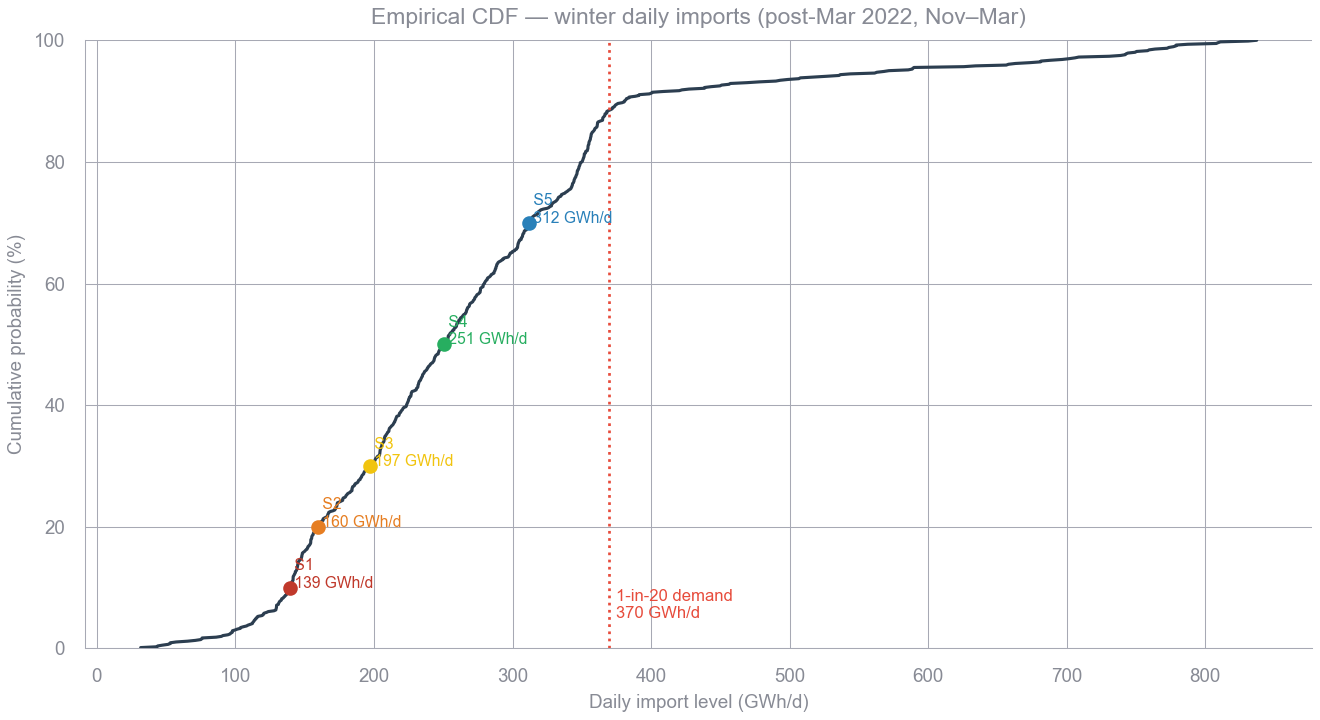

In [10]:
fig = plot.winter_cdf(
    daily,
    scenarios=bsd.DEFAULT_SCENARIOS,
    peak_demand_GWh_d=PEAK_DEMAND_GWH_D,
)

fig;